In [1]:
from pathlib import Path
from collections import defaultdict
from typing import Optional, List
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from scipy.special import log_softmax
from datasets import load_from_disk

In [4]:
def load_results_paths():
    root_results_dir = Path("../experiments")
    results = []
    for dataset in root_results_dir.glob("*"):
        for prompt in dataset.glob("*"):
            for model in prompt.glob("*"):
                for base_method in model.glob("*"):
                    for cal_method in base_method.glob("*"):
                        if cal_method.name == ".cache":
                            continue
                        for path in (cal_method / "predictions").glob("*"):
                            results.append({
                                "dataset": dataset.name,
                                "prompt": prompt.name,
                                "model": model.name,
                                "base_method": base_method.name,
                                "cal_method": cal_method.name,
                                "split": path.name,
                                "results": str(path)
                            })
    return pd.DataFrame(results)


def _compute_metric(logits, targets, metric):
    # Unnorm metrics
    if metric == "accuracy":
        return accuracy_score(targets, logits.argmax(axis=1))
    elif metric == "error_rate":
        return 1 - accuracy_score(targets, logits.argmax(axis=1))
    elif metric == "f1_score":
        return f1_score(targets, logits.argmax(axis=1), average="macro")
    elif metric == "cross_entropy":
        logprobs = log_softmax(logits, axis=1)
        return - np.mean(logprobs[np.arange(len(targets)), targets])

    # Norm metrics
    elif metric == "norm_acc":
        acc = _compute_metric(logits, targets, "accuracy")
        priors = np.tile(np.bincount(targets, minlength=logits.shape[1]) / len(targets), (len(targets), 1))
        naive_acc = _compute_metric(priors, targets, "accuracy")
        return acc / naive_acc
    elif metric == "norm_error_rate":
        er = _compute_metric(logits, targets, "error_rate")
        priors = np.tile(np.bincount(targets, minlength=logits.shape[1]) / len(targets), (len(targets), 1))
        naive_er = _compute_metric(priors, targets, "error_rate")
        return er / naive_er
    elif metric == "nce":
        ce = _compute_metric(logits, targets, "cross_entropy")
        priors = np.tile(np.bincount(targets, minlength=logits.shape[1]) / len(targets), (len(targets), 1))
        naive_ce = _compute_metric(priors, targets, "cross_entropy")
        return ce / naive_ce
    else:
        raise ValueError(f"Metric {metric} is not supported")


def compute_metric(logits, targets, metric, bootstrap, random_state):
    if bootstrap == 0:
        return [_compute_metric(logits, targets, metric)]
    
    rs = np.random.RandomState(random_state)
    values = []
    for _ in range(bootstrap):
        idx = rs.choice(len(targets), len(targets), replace=True)
        values.append(_compute_metric(logits[idx], targets[idx], metric))
    return values


def compute_results(metrics, bootstrap, random_state, show_test=False):
    df_results = load_results_paths()
    
    for metric in metrics:
        df_results[metric] = ""
        df_results[f"{metric}:mean"] = np.nan
        df_results[f"{metric}:std"] = np.nan

    for idx, row in tqdm(df_results.iterrows(), total=len(df_results)):
        row_results = load_from_disk(row["results"]).with_format("numpy")
        logits = row_results["logits"].astype(float)
        targets = row_results["label"].astype(int)
        for metric in metrics:
            values = compute_metric(logits, targets, metric, bootstrap, random_state)
            mean = np.mean(values)
            std = np.std(values)
            df_results.loc[idx, metric] = f"{mean:.3f} ± {std:.3f}"
            df_results.loc[idx, f"{metric}:mean"] = mean
            df_results.loc[idx, f"{metric}:std"] = std
    
    df_results.drop(columns=["results"], inplace=True)

    if not show_test:
        df_results = df_results[df_results["split"] != "test"]
    return df_results

metrics = ["norm_error_rate", "nce"]
bootstrap = 100
random_state = 42
df = compute_results(metrics, bootstrap, random_state, show_test=False)
df.loc[:,[c for c in df.columns if ":" not in c ]]

100%|██████████| 6/6 [00:02<00:00,  2.70it/s]


,dataset,prompt,model,base_method,cal_method,split,norm_error_rate,nce
0,dbpedia_large,basic_dbpedia_0-shot_litgpt,lm_tinyllama,no_adaptation_bf16,no_calibration,train,0.665 ± 0.005,1.658 ± 0.018
2,dbpedia_large,basic_dbpedia_0-shot_litgpt,lm_tinyllama,no_adaptation_bf16,no_calibration,validation,0.652 ± 0.019,1.477 ± 0.056
3,dbpedia_large,basic_dbpedia_0-shot_litgpt,lm_tinyllama,no_adaptation_bf16,affine_vector,train,0.465 ± 0.006,0.455 ± 0.005
5,dbpedia_large,basic_dbpedia_0-shot_litgpt,lm_tinyllama,no_adaptation_bf16,affine_vector,validation,0.532 ± 0.017,0.512 ± 0.017


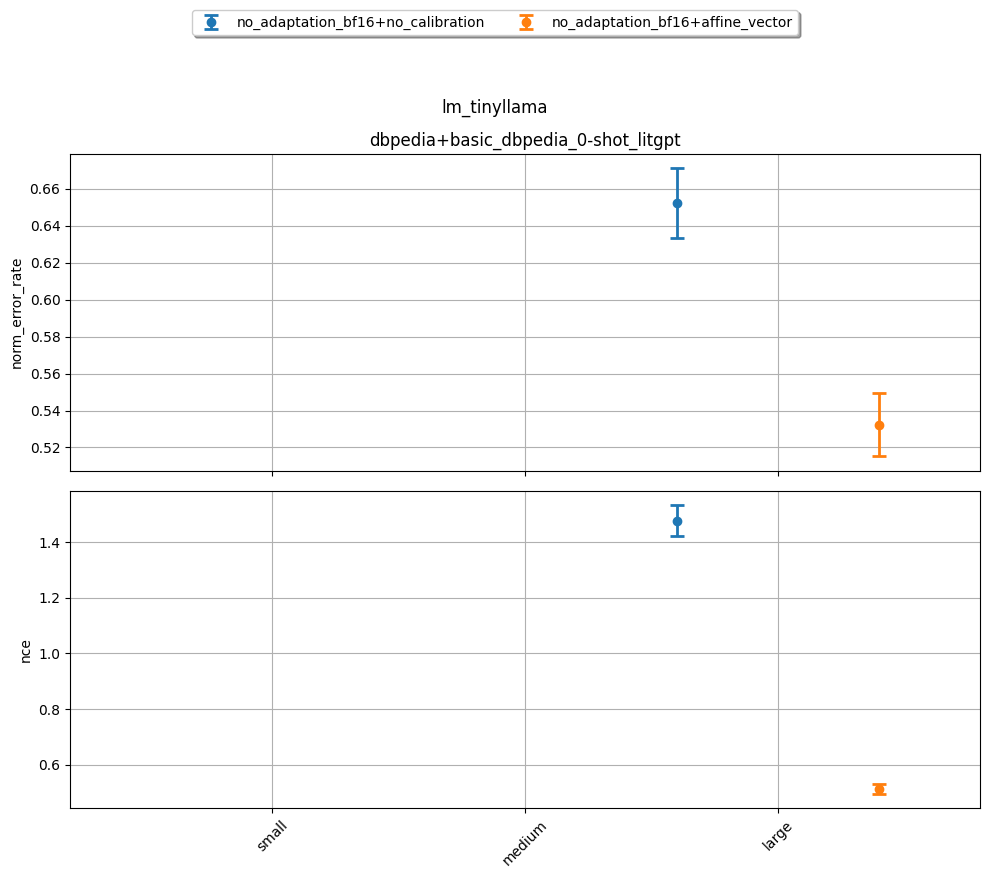

In [5]:
def plot_results(df, metrics, width=.8, test=False):
    df = df[df["split"] == "test"] if test else df[df["split"] == "validation"]

    models = df["model"].unique()
    datasets = (df["dataset"].str.split("_", expand=True)[0] + "+" + df["prompt"]).unique()
    sizes = ["small", "medium", "large"]
    methods = (df["base_method"] + "+" + df["cal_method"]).unique()

    for model in models:
        fig, ax = plt.subplots(len(metrics),len(datasets), figsize=(10, 8), sharex=True)
        if len(metrics) == 1 and len(datasets) == 1:
            ax = np.array([[ax]])
        elif len(metrics) == 1:
            ax = ax[np.newaxis, :]
        elif len(datasets) == 1:
            ax = ax[:, np.newaxis]
        for i, dataset in enumerate(datasets):
            for j, metric in enumerate(metrics):
                for s, size in enumerate(sizes):
                    for m, method in enumerate(methods):
                        mask = \
                            (df["model"] == model) & \
                            (df["dataset"].str.split("_", expand=True)[0] + "+" + df["prompt"] == dataset) & \
                            (df["dataset"].str.contains(size)) & \
                            (df["base_method"] + "+" + df["cal_method"] == method)
                        if mask.sum() == 0:
                            continue
                        mean = df[mask][f"{metric}:mean"].values
                        std = df[mask][f"{metric}:std"].values
                        # centered errorbar
                        ax[j, i].errorbar(
                            s - width / 2 + width / (len(methods) - 1) * m, 
                            mean, 
                            yerr=std, 
                            fmt='o', 
                            label=method,
                            capsize=5,
                            capthick=2,
                            elinewidth=2,
                            color=f"C{m}"
                        )
                ax[j,i].grid(True)
            
            ax[-1, i].set_xticks(range(len(sizes)))
            ax[-1, i].set_xticklabels(sizes, rotation=45)
            ax[-1, i].set_xlim(-width, len(sizes) - (1 - width))
        
        for i, dataset in enumerate(datasets):
            ax[0, i].set_title(dataset)
        for j, metric in enumerate(metrics):
            ax[j, 0].set_ylabel(metric)

        fig.suptitle(model)
        fig.legend(methods, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=len(methods), fancybox=True, shadow=True)
        fig.tight_layout()

plot_results(df, metrics, width = 0.8, test = False)